# Analysis of data by INGV

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from scipy.optimize import curve_fit

import plotly.express as px
import plotly.io as pio

- Earthquake Frequency over year
- Magnitude Distribution over year
- Depth Distribution over year
- Relationship Between Depth and Magnitude

Dataset ready: 215679 earthquakes loaded.


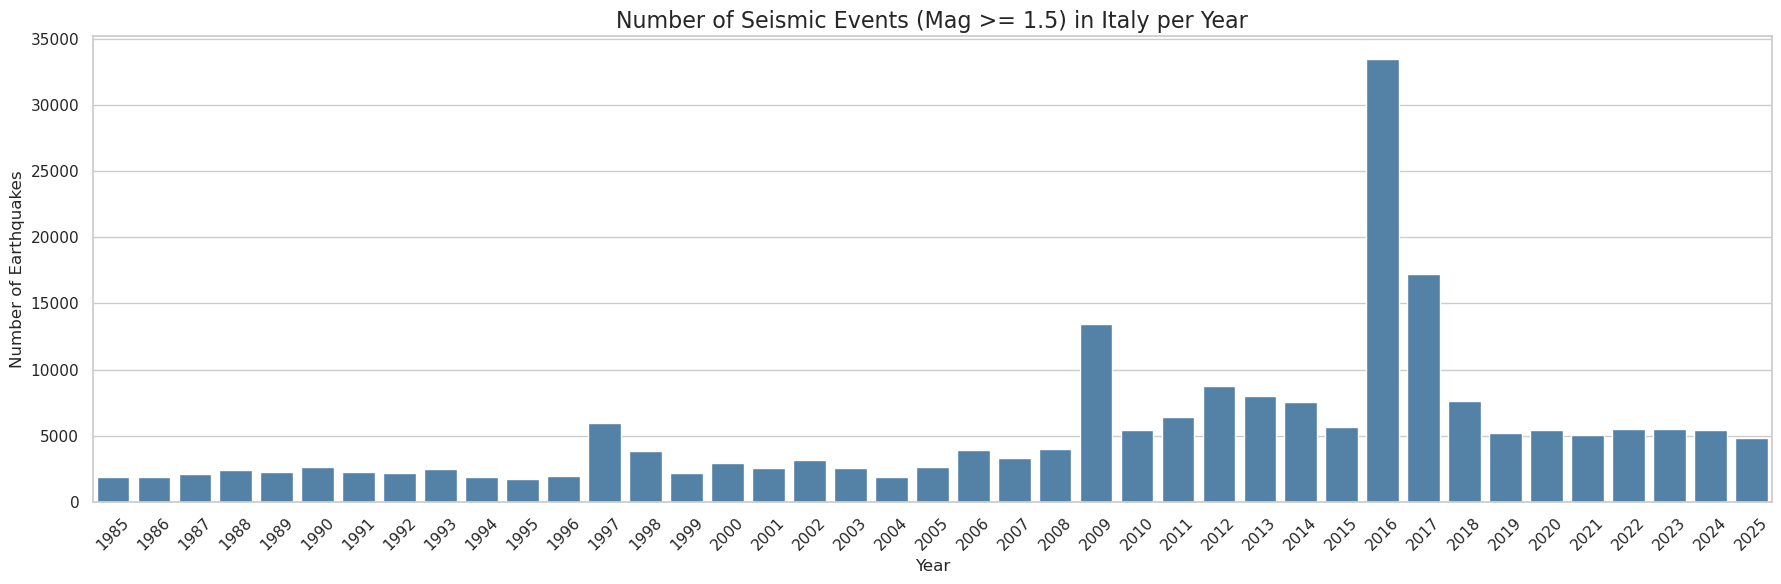

/tmp/ipykernel_30390/825233127.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x='year', y='magnitude', palette='viridis')


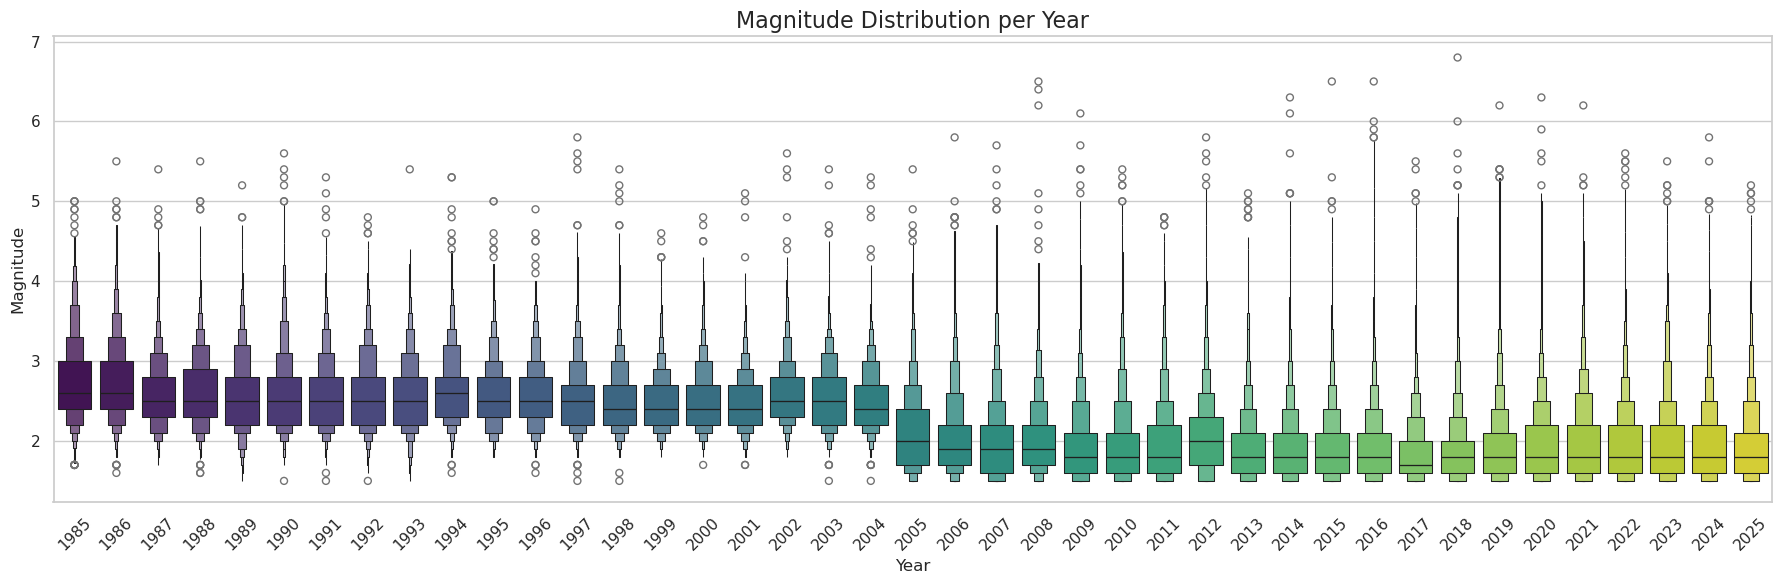

/tmp/ipykernel_30390/825233127.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='year', y='depth_km', palette='magma')


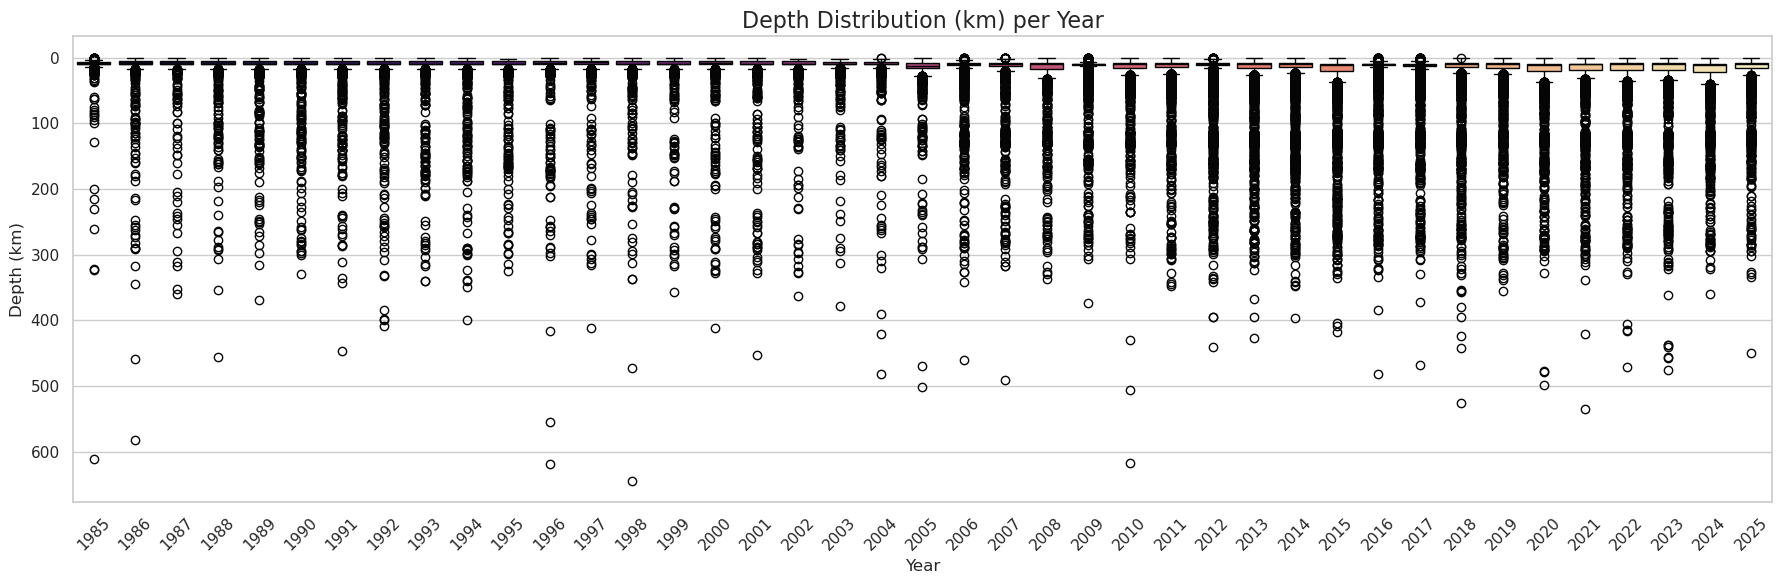

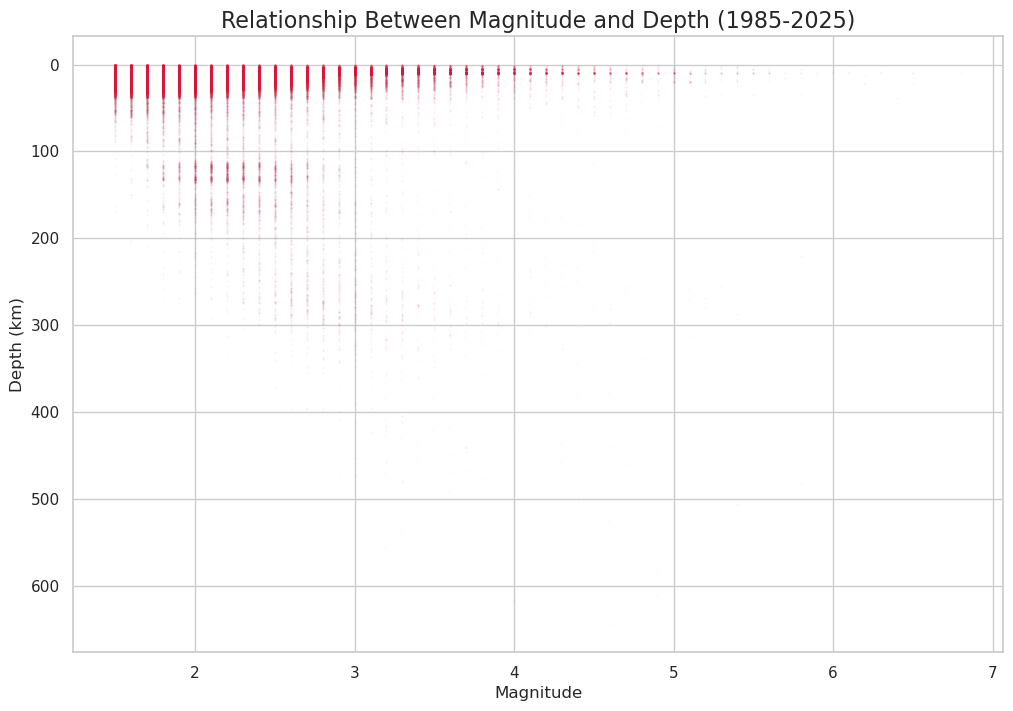

In [4]:
sns.set_theme(style="whitegrid")
%matplotlib inline

df = pd.read_csv("data/INGV/italy_earthquakes_1985_2025.csv")

df['time'] = pd.to_datetime(df['time'], utc=True)
df['year'] = df['time'].dt.year

print(f"Dataset ready: {len(df)} earthquakes loaded.")

plt.figure(figsize=(18, 6))
# Using a bar plot counting years
year_counts = df['year'].value_counts().sort_index()
sns.barplot(x=year_counts.index, y=year_counts.values, color='steelblue')
plt.xticks(rotation=45)
plt.title('Number of Seismic Events (Mag >= 1.5) in Italy per Year', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Number of Earthquakes')
plt.tight_layout()
plt.show()


plt.figure(figsize=(18, 6))
sns.boxenplot(data=df, x='year', y='magnitude', palette='viridis')
plt.xticks(rotation=45)
plt.title('Magnitude Distribution per Year', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Magnitude')
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 6))
sns.boxplot(data=df, x='year', y='depth_km', palette='magma')
plt.gca().invert_yaxis() 
plt.xticks(rotation=45)
plt.title('Depth Distribution (km) per Year', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Depth (km)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='magnitude', y='depth_km', alpha=0.05, s=2, color='crimson')
plt.gca().invert_yaxis()
plt.title('Relationship Between Magnitude and Depth (1985-2025)', fontsize=16)
plt.xlabel('Magnitude')
plt.ylabel('Depth (km)')
plt.show()

## Interactive visualization of map with data 

In [27]:
pio.renderers.default = 'iframe' 

df = pd.read_csv("data/INGV/italy_earthquakes_1985_2025.csv")
mag_cut = 5
df_map = df[df['magnitude'] >= mag_cut].copy()
print(f"Plotting {len(df_map)} significant earthquakes (Mag >= {mag_cut})...")

fig = px.scatter_mapbox(
    df_map, 
    lat="latitude", 
    lon="longitude", 
    color="magnitude",
    size="magnitude",
    color_continuous_scale="matter",
    zoom=4.5,
    center={"lat": 41.9, "lon": 12.5},
    mapbox_style="carto-positron",
    hover_name="time",
    hover_data={
        "latitude": ":.3f", 
        "longitude": ":.3f", 
        "depth_km": True,
        "magnitude": True
    },
    title=f"Interactive Seismic Map: Italy (Mag >= {mag_cut})"
)

fig.update_layout(margin={"r": 0, "t": 40, "l": 0, "b": 0})
fig.show()

Plotting 178 significant earthquakes (Mag >= 5)...


/tmp/ipykernel_30390/757330531.py:8: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


---

---

---

---

# ***Gutenberg-Richter Law (2005-2025)***

The Gutenberg–Richter law is an empirical relationship that describes the frequency distribution of earthquake magnitudes in a given region and time period.

It states that smaller earthquakes occur much more frequently than larger ones. The relationship is commonly expressed as:
$$
\log_{10} N(M) = a - bM
$$

where:
- $N(M)$ is the number of earthquakes with magnitude greater than or equal to $M$,
- $a$ is a constant that represents the overall level of seismic activity. It depends on the seismicity of the region: higher $a$ values indicate more active regions.
- $b$ is a parameter that describes the relative proportion of small to large earthquakes. It typically has a value close to 1: $b \approx 1$ means that for each unit increase in magnitude, the number of earthquakes decreases by a factor of about 10. Variations in $b$ can indicate differences in tectonic conditions or stress regimes.
- $M$ is the earthquake magnitude.

In [6]:
sns.set_theme(style="whitegrid")

# DATA UPLOAD:
print("Loading the filtered Italian dataset...")
df = pd.read_csv("data/INGV/italy_earthquakes_1985_2025.csv")
df['time'] = pd.to_datetime(df['time'], utc=True)
cut_year = 1985
df_net = df[df['time'].dt.year >= cut_year].copy()

print(f"Dataset ready: {len(df)} earthquakes loaded.")

Loading the filtered Italian dataset...
Dataset ready: 215679 earthquakes loaded.


In [17]:

# FUNCTION FOR GUTENBERG-RICHTER LAW: FIT + PLOT ------------------------------------------------------
def fit_gr_law(df, max_mag, plot=False, M_c=1.5):
    """
    Fit Gutenberg-Richter law up to a maximum magnitude.

    Parameters:
    - df: dataframe containing 'magnitude'
    - max_mag: upper magnitude limit for fitting
    - plot: whether to plot the fit
    - M_c: completeness magnitude (lower bound)

    Returns:
    - dict with fitted parameters
    """

    # Count number of events per magnitude
    mag_counts = df['magnitude'].value_counts().sort_index()
    # Compute cumulative counts from high to low magnitude
    cumulative_N = mag_counts[::-1].cumsum()[::-1]

    # Select only the magnitude range used for fitting
    fit_mask = (cumulative_N.index >= M_c) & (cumulative_N.index <= max_mag)
    mags_for_fit = cumulative_N.index[fit_mask]
    logN_for_fit = np.log10(cumulative_N.values[fit_mask])

    # Perform linear regression: log10(N) = a - bM
    slope, intercept, r_value, p_value, std_err = linregress(mags_for_fit, logN_for_fit)
    # Convert slope to b-value (note the minus sign)
    b_value = -slope
    a_value = intercept

    # Optional plotting
    if plot:
        plt.figure(figsize=(10, 5))

        # Scatter plot of observed cumulative data
        plt.scatter(cumulative_N.index,
                    np.log10(cumulative_N.values),
                    alpha=0.7,
                    edgecolors='k',
                    label='Observed Data')

        # Plot fitted Gutenberg–Richter line
        fit_line = a_value - b_value * mags_for_fit
        plt.plot(mags_for_fit,
                 fit_line,
                 linewidth=2,
                 label=f'Fit up to M={max_mag} (b={b_value:.2f}), (a={a_value:.2f})')

        # Labels and layout
        plt.title(f'Gutenberg-Richter Fit (M ≤ {max_mag})')
        plt.xlabel('Magnitude (M)')
        plt.ylabel('log10 N (≥ M)')
        plt.legend()
        plt.tight_layout()
        plt.show()

    # Return results as dictionary
    return {
        'max_mag': max_mag,
        'a_value': a_value,
        'b_value': b_value,
        'r_squared': r_value**2,
        'std_err': std_err
    }

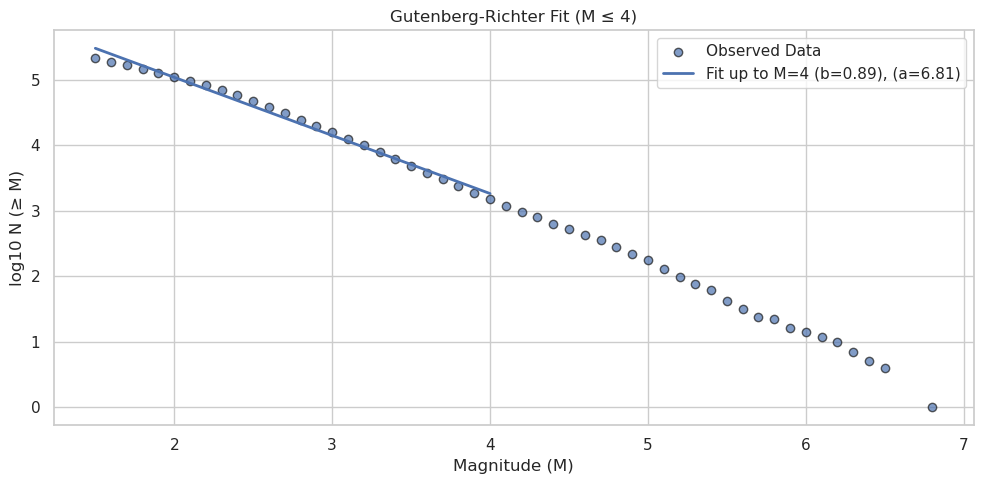

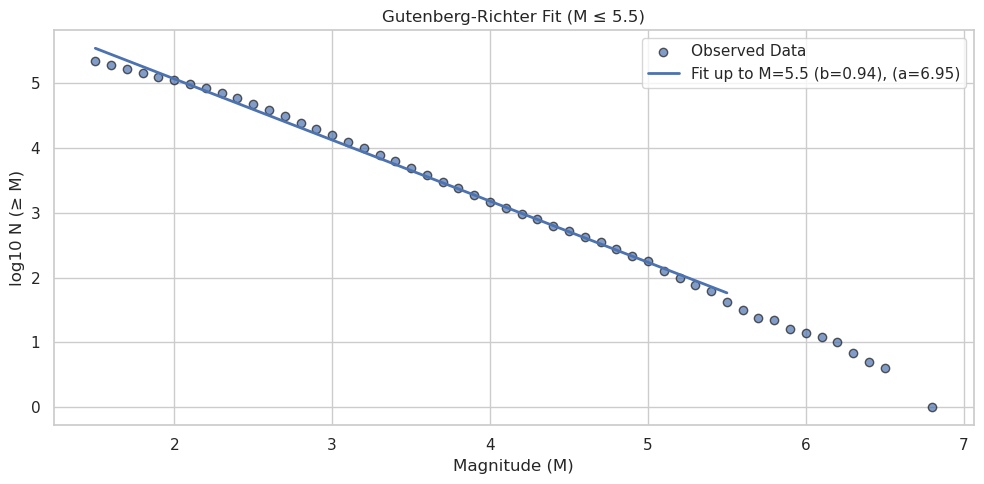

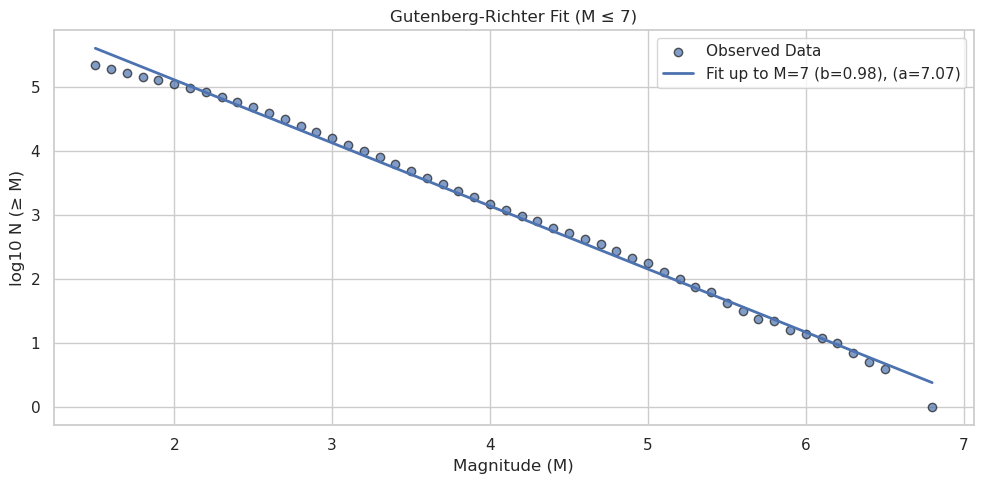

In [18]:
# List of maximum magnitudes to test
max_mags = [4, 4.5, 5, 5.5, 6, 6.5, 7]
# Decide which ones to plot (same length as max_mags)
plot_flags = [True, False, False, True, False, False, True]

# Store results
results = []

# Loop over all configurations
for max_mag, do_plot in zip(max_mags, plot_flags):
    res = fit_gr_law(df_net, max_mag=max_mag, plot=do_plot)   # Call the fitting function
    results.append(res)       # Append result to list

In [19]:
# Convert results list into a DataFrame
results_df = pd.DataFrame(results)

# Sort by max magnitude for clarity
results_df = results_df.sort_values(by='max_mag')

# Display table
print(results_df)

   max_mag   a_value   b_value  r_squared   std_err
0      4.0  6.808180  0.886681   0.989925  0.018259
1      4.5  6.871472  0.913239   0.993139  0.014095
2      5.0  6.896030  0.922812   0.995500  0.010640
3      5.5  6.951261  0.942981   0.996036  0.009526
4      6.0  7.011826  0.963954   0.996125  0.009064
5      6.5  7.042750  0.973985   0.996844  0.007828
6      7.0  7.074208  0.983736   0.995705  0.009137


**R-squared (R²)**—also called the *coefficient of determination*—measures how well your model explains the variability of the data in Machine Learning and statistics.

$R^2$ answers this question: “How much better is my model compared to just using the average value?”
* **R² = 1** → perfect fit (model explains everything)
* **R² = 0** → no better than predicting the mean
* **R² < 0** → worse than predicting the mean

It is computed as:
$$
R^2 = 1 - \frac{SS_{res}}{SS_{tot}}
$$
where:
* $SS_{res} = \sum (y_i - \hat{y}_i)^2$ is the residual sum of squares (unexplained error)
* $SS_{tot} = \sum (y_i - \bar{y})^2$ is the total sum of squares (total variability in data)

and:
* $y_i$: true data values
* $\hat{y}_i$: model predictions
* $\bar{y}$: mean of observed data

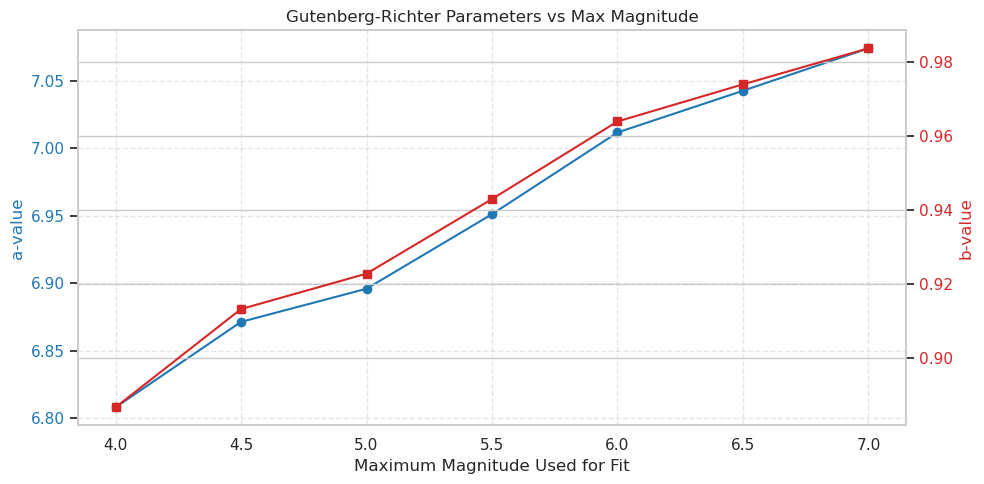

In [21]:
# Create figure with two y-axes (since a and b have different scales)
fig, ax1 = plt.subplots(figsize=(10, 5))

# ---- Plot a-value ----
ax1.plot(results_df['max_mag'],
         results_df['a_value'],
         marker='o', color='tab:blue', label='a-value')
ax1.set_xlabel('Maximum Magnitude Used for Fit')
ax1.set_ylabel('a-value', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# ---- Create second y-axis for b-value ----
ax2 = ax1.twinx()
ax2.plot(results_df['max_mag'],
         results_df['b_value'],
         marker='s', color='tab:red', label='b-value')
ax2.set_ylabel('b-value', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

# ---- Title and grid ----
plt.title('Gutenberg-Richter Parameters vs Max Magnitude')
ax1.grid(True, linestyle='--', alpha=0.5)

# ---- Show plot ----
plt.tight_layout()
plt.show()

The above plot shows how the parameters $a$ and $b$ of the GR law changes wrt the change in the magnitude upper lmit.

---

---

---

---

# ***Omori Law***

Omori's law is an empirical relationship used to describe how the frequency of aftershocks decreases over time following a main earthquake.

In his 1894 study, Fusakichi Omori observed that the rate of aftershocks decays approximately as the inverse of the elapsed time $t$ since the main shock. The original formulation is:
$$
n(t) = \frac{K}{c + t}
$$

where:
- $n(t)$ is the rate (number per unit time) of aftershocks at time $t$,
- $K$ and $c$ are empirical constants that vary between different earthquake sequences,
- $t$ is the time elapsed since the main shock.

In 1961, Utsu proposed a generalized version of Omori's law to better fit observational data. This modified form is:
$$
n(t) = \frac{K}{(c + t)^p}
$$
where $p$ is an additional parameter that controls the decay rate. Typically, $p$ lies in the range $0.7 \leq p \leq 1.5$. This modified formulation is now more commonly used in seismology.

According to these relations the rate of aftershocks decreases rapidly over time and the inverse-time dependence allows estimation of the probability of future aftershocks.

For example if the probability of aftershocks on the first day is $P$, it is roughly halved on the second day, and reduced to about one-tenth by the tenth day.


Search for strongest earthquakes in Italy in 1985-2026:

In [24]:
df_net[ df_net["magnitude"] >= 6 ]

,time,latitude,longitude,depth_km,magnitude
61147,2008-02-20 18:27:04+00:00,36.2700,21.75000,21.0,6.2
61215,2008-02-14 10:09:22+00:00,36.5000,21.80000,21.0,6.5
62547,2008-06-08 12:25:22+00:00,38.0100,21.44000,39.0,6.4
71989,2009-04-06 01:32:40.400000+00:00,42.3420,13.38000,8.3,6.1
107128,2014-01-26 13:55:44+00:00,38.2300,20.48000,10.0,6.3
108418,2014-02-03 03:08:46+00:00,38.2900,20.31000,10.0,6.1
119682,2015-11-17 07:10:08.322000+00:00,38.7413,20.52360,10.1,6.5
127172,2016-08-24 01:36:32+00:00,42.6983,13.23350,8.1,6.0
133723,2016-10-30 06:40:17.320000+00:00,42.8303,13.10920,10.0,6.5
176969,2018-10-30 15:12:01.163000+00:00,37.4889,20.57740,10.0,6.0


## ***Aftershock Decay on Amatrice 2016***

In [28]:
pio.renderers.default = 'iframe' 

# Isolate the Amatrice 2016 Sequence
mainshock_time = pd.to_datetime('2016-08-24 01:36:32', utc=True) # Exact time of Amatrice
end_time = mainshock_time + pd.Timedelta(days=90) # Look at 90 days of aftershocks
mag_cut = 1.5  # magnitude lower limit
# Filter by time and space
df_search_zone = df_net[
    (df_net['time'] >= mainshock_time) & 
    (df_net['time'] <= end_time) &
    (df_net['latitude'] >= 42.0) & (df_net['latitude'] <= 43.5) &
    (df_net['longitude'] >= 12.5) & (df_net['longitude'] <= 14.0) &
    (df_net['magnitude'] >= mag_cut)
].copy()

print(f"Plotting {len(df_search_zone)} significant earthquakes (Mag >= {mag_cut})...")

fig = px.scatter_mapbox(
    df_search_zone, 
    lat="latitude", lon="longitude", 
    color="magnitude", size="magnitude", color_continuous_scale="matter",
    zoom=4.5, center={"lat": 41.9, "lon": 12.5},
    mapbox_style="carto-positron", hover_name="time",
    hover_data={
        "latitude": ":.3f", 
        "longitude": ":.3f", 
        "depth_km": True,
        "magnitude": True
    },
    title=f"Interactive Seismic Map: Italy (Mag >= {mag_cut})"
)

fig.update_layout(margin={"r": 0, "t": 40, "l": 0, "b": 0})
fig.show()

Plotting 22466 significant earthquakes (Mag >= 1.5)...


/tmp/ipykernel_30390/1442328847.py:18: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


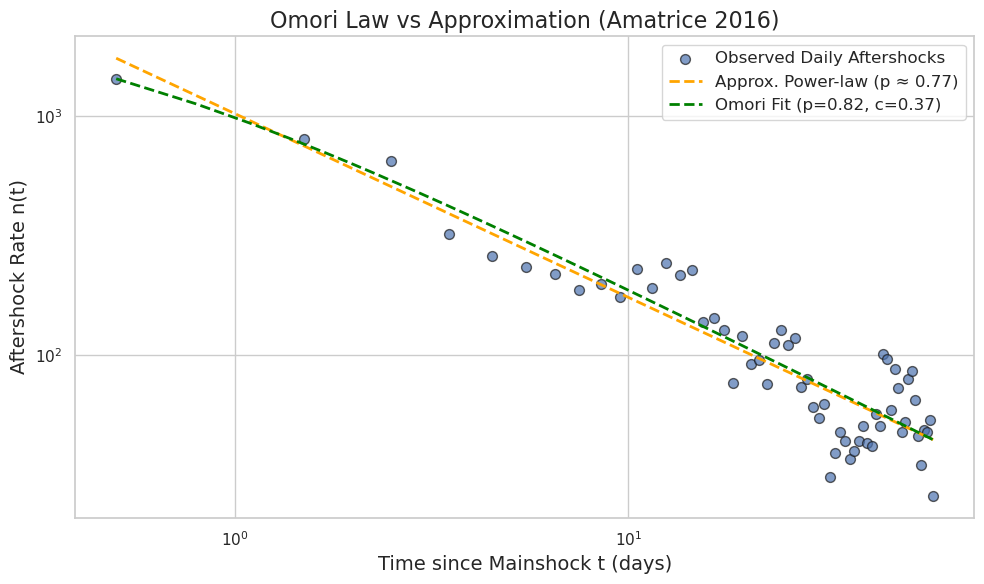

Approximate p (log-log fit): 0.767
Omori fit parameters: K=1271.621, c=0.369, p=0.819


In [35]:
# 1. Define Omori law function (full formulation)
def omori_law(t, K, c, p):
    return K / (c + t)**p

# -------------------------------
# 2. Isolate the Amatrice sequence
mainshock_time = pd.to_datetime('2016-08-24 01:36:32', utc=True)  # mainshock origin time
end_time = mainshock_time + pd.Timedelta(days=60)  # analyze 90 days after

# Filter dataset in time and space (region around Amatrice)
df_amatrice = df_net[
    (df_net['time'] >= mainshock_time) & 
    (df_net['time'] <= end_time) &
    (df_net['latitude'] >= 42.0) & (df_net['latitude'] <= 43.5) &
    (df_net['longitude'] >= 12.5) & (df_net['longitude'] <= 14.0)
].copy()

# -------------------------------
# 3. Compute time since mainshock
df_amatrice['days_since_mainshock'] = (
    (df_amatrice['time'] - mainshock_time).dt.total_seconds() / (24 * 3600)
)

# -------------------------------
# 4. Compute daily counts n(t)
bins = np.arange(0, 61, 1)  # 1-day bins for first 60 days
daily_counts, bin_edges = np.histogram(df_amatrice['days_since_mainshock'], bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Remove zero counts (needed for log-log plotting)
mask = daily_counts > 0
t_valid = bin_centers[mask]
n_t_valid = daily_counts[mask]

# -------------------------------
# 5. Approximate fit (log-log linear)
log_t = np.log10(t_valid)
log_n = np.log10(n_t_valid)
# Linear regression in log-log space
slope, intercept, _, _, _ = linregress(log_t, log_n)
p_approx = -slope  # slope corresponds to -p
# Reconstruct fitted curve in linear space
n_fit_approx = 10**(intercept + slope * log_t)

# -------------------------------
# 6. Full Omori fit (nonlinear)
# Initial guesses for parameters (important for convergence)
initial_guess = [max(n_t_valid), 0.1, 1.0]  # K, c, p
# Fit using nonlinear least squares
params, _ = curve_fit(omori_law, t_valid, n_t_valid, p0=initial_guess, maxfev=10000)
K_fit, c_fit, p_fit = params  # extract fitted parameters
# Generate smooth curve for plotting
t_smooth = np.linspace(min(t_valid), max(t_valid), 200)
n_fit_omori = omori_law(t_smooth, K_fit, c_fit, p_fit)

# -------------------------------
# 7. Plot everything together
plt.figure(figsize=(10, 6))

# Scatter observed data
plt.scatter(t_valid, n_t_valid,
            alpha=0.7, edgecolors='k', s=50, label='Observed Daily Aftershocks')

# Plot approximate power-law (log-log linear fit)
plt.plot(t_valid, n_fit_approx,
         linestyle='--', linewidth=2, color="Orange", label=fr'Approx. Power-law (p ≈ {p_approx:.2f})')

# Plot full Omori law fit
plt.plot(t_smooth, n_fit_omori,
         linestyle='--', linewidth=2, color="Green", label=fr'Omori Fit (p={p_fit:.2f}, c={c_fit:.2f})')

# Log-log scale (essential for Omori behavior)
plt.xscale('log')
plt.yscale('log')

# Labels and title
plt.title('Omori Law vs Approximation (Amatrice 2016)', fontsize=16)
plt.xlabel('Time since Mainshock t (days)', fontsize=14)
plt.ylabel('Aftershock Rate n(t)', fontsize=14)

plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# -------------------------------
# 8. Print comparison
# -------------------------------
print(f"Approximate p (log-log fit): {p_approx:.3f}")
print(f"Omori fit parameters: K={K_fit:.3f}, c={c_fit:.3f}, p={p_fit:.3f}")

---

---

---

## ***Aftershock Decay on L'Aquila 2009***

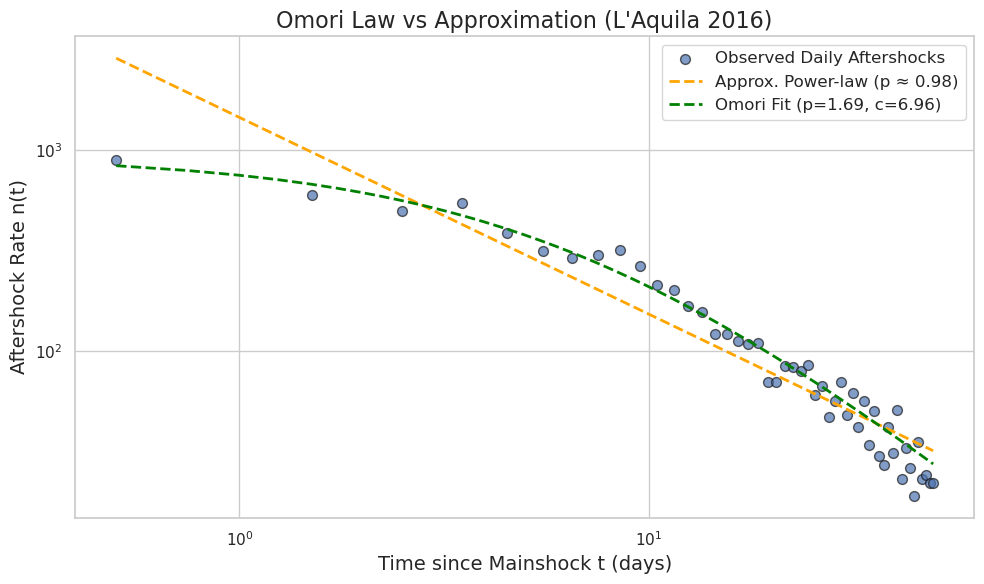

Approximate p (log-log fit): 0.980
Omori fit parameters: K=24945.044, c=6.961, p=1.690


In [43]:
# -------------------------------
# 2. Isolate the L'Aquila sequence (2009 mainshock)
mainshock_time = pd.to_datetime('2009-04-06 01:32:40.400000+00:00', utc=True)  # correct origin time
days_after=50
end_time = mainshock_time + pd.Timedelta(days=days_after)  # analyze 90 days after

# Filter dataset in time and space (region around aquila)
df_aquila = df_net[
    (df_net['time'] >= mainshock_time) & 
    (df_net['time'] <= end_time) &
    (df_net['latitude'] >= 41.5) & (df_net['latitude'] <= 43) &
    (df_net['longitude'] >= 12.5) & (df_net['longitude'] <= 14.0)
].copy()

# -------------------------------
# 3. Compute time since mainshock
df_aquila['days_since_mainshock'] = (
    (df_aquila['time'] - mainshock_time).dt.total_seconds() / (24 * 3600)
)

# -------------------------------
# 4. Compute daily counts n(t)
bins = np.arange(0, days_after+1, 1)  # 1-day bins for first 60 days
daily_counts, bin_edges = np.histogram(df_aquila['days_since_mainshock'], bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Remove zero counts (needed for log-log plotting)
mask = daily_counts > 0
t_valid = bin_centers[mask]
n_t_valid = daily_counts[mask]

# -------------------------------
# 5. Approximate fit (log-log linear)
log_t = np.log10(t_valid)
log_n = np.log10(n_t_valid)
# Linear regression in log-log space
slope, intercept, _, _, _ = linregress(log_t, log_n)
p_approx = -slope  # slope corresponds to -p
# Reconstruct fitted curve in linear space
n_fit_approx = 10**(intercept + slope * log_t)

# -------------------------------
# 6. Full Omori fit (nonlinear)
# Initial guesses for parameters (important for convergence)
initial_guess = [max(n_t_valid), 0.1, 1.0]  # K, c, p
# Fit using nonlinear least squares
params, _ = curve_fit(omori_law, t_valid, n_t_valid, p0=initial_guess, maxfev=10000)
K_fit, c_fit, p_fit = params  # extract fitted parameters
# Generate smooth curve for plotting
t_smooth = np.linspace(min(t_valid), max(t_valid), 200)
n_fit_omori = omori_law(t_smooth, K_fit, c_fit, p_fit)

# -------------------------------
# 7. Plot everything together
plt.figure(figsize=(10, 6))

# Scatter observed data
plt.scatter(t_valid, n_t_valid,
            alpha=0.7, edgecolors='k', s=50, label='Observed Daily Aftershocks')

# Plot approximate power-law (log-log linear fit)
plt.plot(t_valid, n_fit_approx,
         linestyle='--', linewidth=2, color="Orange", label=fr'Approx. Power-law (p ≈ {p_approx:.2f})')

# Plot full Omori law fit
plt.plot(t_smooth, n_fit_omori,
         linestyle='--', linewidth=2, color="Green", label=fr'Omori Fit (p={p_fit:.2f}, c={c_fit:.2f})')

# Log-log scale (essential for Omori behavior)
plt.xscale('log')
plt.yscale('log')

# Labels and title
plt.title('Omori Law vs Approximation (L\'Aquila 2016)', fontsize=16)
plt.xlabel('Time since Mainshock t (days)', fontsize=14)
plt.ylabel('Aftershock Rate n(t)', fontsize=14)

plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

# -------------------------------
# 8. Print comparison
# -------------------------------
print(f"Approximate p (log-log fit): {p_approx:.3f}")
print(f"Omori fit parameters: K={K_fit:.3f}, c={c_fit:.3f}, p={p_fit:.3f}")

# COMMENTS ON OMORI

We fitted the aftershock decay using both an approximate power-law and the full Omori law:

$$
n(t) = \frac{K}{(c + t)^p}
$$

Results

* **Amatrice (2016)**

  * Approximate: $p \approx 0.77$
  * Omori fit: $K \approx 1271.6$, $c \approx 0.37$, $p \approx 0.82$

* **L'Aquila (2009)**

  * Approximate: $p \approx 0.98$
  * Omori fit: $K \approx 24945.0$, $c \approx 6.96$, $p \approx 1.69$

For **L'Aquila** there is a strong discrepancy.



### $p$ (decay exponent)

Controls how fast aftershocks decay:
  * $p \approx 1$ → typical seismic decay
  * $p < 1$ → slower decay
  * $p > 1$ → faster decay

* **Amatrice** $  p \approx 0.8 $  → relatively **slow decay**, sustained aftershock activity
* **L'Aquila**: $ p \approx 1.69 $  → **very fast decay**, aftershocks decrease rapidly

### $c$ (time offset)

Represents a **delay or smoothing at early times**. Physically related to:

  * catalog incompleteness
  * overlapping seismic processes
  * detection limitations right after the mainshock

* **Amatrice**: $ c \approx 0.37 $  → negligible → good early-time detection
* **L'Aquila**: $ c \approx 6.96 $ → very large → early aftershocks are **not well captured or strongly affected**


### $K$ (productivity)

Controls total number of aftershocks. Much larger for L'Aquila:
  $$
  K_{\text{Aquila}} \gg K_{\text{Amatrice}}
  $$
  → indicates a **much more productive sequence**


